# F4 — Visualización y comunicación de resultados
**Grupo 5 · Víctor Bravo Barrera, Nayadeth Garrido Ibáñez y Mauricio Cid**

Este notebook cierra el proyecto: transforma en gráficos los resultados calculados en F2 y F3 y los interpreta frente a la hipótesis del análisis. No introduce reglas nuevas de limpieza ni de cálculo; reutiliza las clases de lectura, limpieza y validación y la función de proporciones seleccionada en F3.

La unidad de observación de los datos es una oferta asociada a un ítem. Los dos primeros gráficos resumen ofertas; el tercero resume licitaciones, porque el plazo de cierre es un atributo del proceso.

**Recorrido:** entorno → datos → hipótesis → preparación para visualizar → tres gráficos con su interpretación → pruebas → síntesis → reproducibilidad.

## 1. Entorno
### 1.1. Importaciones y ubicación del proyecto
Las funciones de visualización están en `src/visualizacion.py`. El notebook solo las invoca, guarda las figuras y comenta los resultados.

In [1]:
from pathlib import Path
import sys
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

raiz = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / 'src/visualizacion.py').exists())
if str(raiz) not in sys.path:
    sys.path.insert(0, str(raiz))

from src.entorno import versiones_entorno
from src.datos import COLUMNAS_ANALISIS, TIPOS_ANALISIS, ContratoEsquema, LectorCSV, sha256_archivo
from src.pipeline import LimpiadorLicitaciones
from src.validacion import ValidadorDatasetProcesado
from src.analisis import tabla_proporciones, tabla_proporciones_agrupada
from src.visualizacion import (ETIQUETAS_TAMANO, ETIQUETAS_TIPO, grafico_plazos,
                               grafico_proporciones, guardar_figura, plazos_por_licitacion)

FIGURAS = raiz / 'F4/figuras'   # las mismas imágenes se usan en el informe y en la presentación

### 1.2. Versiones utilizadas
Además de las dependencias de las fases anteriores, F4 usa Matplotlib y Seaborn, declaradas en `requirements.txt`.

In [2]:
print(sys.version)
versiones = {**versiones_entorno(), 'matplotlib': matplotlib.__version__, 'seaborn': sns.__version__}
display(pd.DataFrame(list(versiones.items()), columns=['Dependencia', 'Versión']))

3.14.7 (tags/v3.14.7:823f032, Aug  5 2026, 10:51:32) [MSC v.1944 64 bit (AMD64)]


,Dependencia,Versión
0,numpy,2.3.5
1,pandas,3.0.1
2,jupyterlab,4.6.4
3,ipykernel,7.4.0
4,nbformat,5.11.1
5,nbconvert,7.17.1
6,nbclient,0.11.0
7,matplotlib,3.11.2
8,seaborn,0.13.2


## 2. Datos
### 2.1. Lectura, limpieza y validación
Se repite el flujo de F3: se comprueba la huella SHA-256 del archivo original, se leen solo las siete columnas del análisis con sus tipos, se limpia con `LimpiadorLicitaciones` y se valida con las seis reglas de `ValidadorDatasetProcesado`. Si una regla falla, el notebook se detiene antes de graficar.

In [3]:
ruta = raiz / 'data/raw/licitaciones_salud_marzo_2026.csv'
assert sha256_archivo(ruta) == '490d9209a10d387011d481b72b7891f26e997974ec2cf9dfc518aa4a08552232'

lector = LectorCSV(ContratoEsquema(('TamanoProveedor', 'TipoLicitacion', 'EstadoLicitacion', 'ResultadoOferta')),
                   columnas=COLUMNAS_ANALISIS, tipos=TIPOS_ANALISIS)
raw = lector.leer(ruta)
limpiador = LimpiadorLicitaciones()
datos = limpiador.limpiar(raw)
validacion = ValidadorDatasetProcesado().validar(datos, len(raw))

resumen = limpiador.ultima_ejecucion
display(pd.DataFrame({'Etapa': ['Lectura', 'Limpieza'],
                      'Filas': [resumen['filas_entrada'], resumen['filas_salida']],
                      'Columnas': [resumen['columnas_entrada'], resumen['columnas_salida']]}))
print('Reglas de calidad superadas:', validacion['reglas_superadas'], '-', ', '.join(validacion['detalle_reglas']))

,Etapa,Filas,Columnas
0,Lectura,44226,7
1,Limpieza,44226,10


Reglas de calidad superadas: 6 - columnas_vacias_descartadas, integridad_filas, columnas_obligatorias, resultado_oferta, fechas, variables_derivadas


Se conservan las 44.226 ofertas. La limpieza añade las tres variables derivadas (`oferta_ganadora`, `licitacion_adjudicada` y `plazo_cierre_dias`) y las seis reglas de calidad se superan.

## 3. Hipótesis y preguntas del análisis
El objetivo del proyecto es describir cómo varía la proporción de ofertas ganadoras según el tamaño del proveedor y el tipo de licitación.

- **Hipótesis.** La proporción de ofertas ganadoras aumenta con el tamaño del proveedor: las empresas grandes ganan una mayor parte de sus ofertas que las micro y pequeñas.
- **Pregunta 1.** ¿Cuánto difiere esa proporción entre tamaños de proveedor? → Gráfico 1.
- **Pregunta 2.** ¿Cambia la proporción según el tipo de licitación? → Gráfico 2.
- **Pregunta 3.** ¿Se diferencian los tipos de licitación en el plazo que dan para ofertar? → Gráfico 3.

El análisis es descriptivo: las diferencias observadas no establecen causalidad.

## 4. Preparación de los datos para visualizar
### 4.1. Tablas de proporciones
Los dos primeros gráficos se construyen sobre las tablas que entrega `tabla_proporciones_agrupada`, la variante seleccionada en F3. Antes de usarlas se comprueba que coinciden con la función de referencia de F2: así los gráficos muestran exactamente las cifras de las entregas anteriores.

In [4]:
por_tamano = tabla_proporciones_agrupada(datos, 'TamanoProveedor')
por_tipo = tabla_proporciones_agrupada(datos, 'TipoLicitacion')
for grupo, tabla in (('TamanoProveedor', por_tamano), ('TipoLicitacion', por_tipo)):
    pd.testing.assert_frame_equal(tabla, tabla_proporciones(datos, grupo))   # misma tabla que F2
display(por_tamano)

,Ganadora,Perdedora,Sin resultado válido,All,% Ganadora,% Perdedora
TamanoProveedor,,,,,,
Grande,12575,6255,0,18830,66.78,33.22
Mediana,4982,4001,0,8983,55.46,44.54
Micro,1680,1554,0,3234,51.95,48.05
NoClasificado,1803,1576,0,3379,53.36,46.64
Pequeña,5022,4577,0,9599,52.32,47.68
All,26062,17963,0,44025,59.20,40.80


In [5]:
display(por_tipo)

,Ganadora,Perdedora,Sin resultado válido,All,% Ganadora,% Perdedora
TipoLicitacion,,,,,,
Licitación Privada Mayor a 1000 UTM,62,10,0,72,86.11,13.89
Licitación Privada Mayor a 5000 (I2),1,1,0,2,50.00,50.00
Licitación Privada entre 100 y 1000 UTM.,11,1,0,12,91.67,8.33
Licitación Pública Entre 100 y 1000 UTM (LE),14686,8904,0,23590,62.26,37.74
Licitación Pública Mayor 1000 UTM (LP),8066,6328,0,14394,56.04,43.96
Licitación Pública Mayor a 5000 (LR),1652,1559,0,3211,51.45,48.55
Licitación Pública Menor a 100 UTM (L1),1584,1160,0,2744,57.73,42.27
All,26062,17963,0,44025,59.20,40.80


Cada porcentaje usa como denominador las ofertas con resultado válido de su propio grupo, en procesos adjudicados (44.025 ofertas). Ninguna oferta queda sin resultado válido. Tres tipos de licitación privada reúnen entre 2 y 72 ofertas: sus porcentajes se muestran, pero se distinguen en el gráfico por su bajo respaldo.

### 4.2. Plazos por licitación
El plazo de cierre se repite en todas las ofertas de una misma licitación. `plazos_por_licitacion` deja una fila por proceso y verifica que cada licitación tenga un único tipo y un único plazo. Resumir por oferta daría más peso a los procesos con más ítems y oferentes.

In [6]:
plazos = plazos_por_licitacion(datos)
print('Ofertas:', len(datos), '| Licitaciones:', len(plazos))
resumen_plazos = (plazos.assign(Tipo=plazos.TipoLicitacion.map(ETIQUETAS_TIPO))
                  .groupby('Tipo').plazo_cierre_dias
                  .agg(Licitaciones='size', Mediana='median', Q25=lambda s: s.quantile(.25),
                       Q75=lambda s: s.quantile(.75), Máximo='max')
                  .sort_values('Mediana', ascending=False).round(1))
display(resumen_plazos)

Ofertas: 44226 | Licitaciones: 1864


,Licitaciones,Mediana,Q25,Q75,Máximo
Tipo,,,,,
Pública mayor a 5.000 UTM (LR),248,32.0,30.2,32.9,61.0
Privada mayor a 5.000 UTM (I2),1,29.9,29.9,29.9,29.9
Pública mayor a 1.000 UTM (LP),599,20.0,13.0,21.0,43.0
Privada mayor a 1.000 UTM,5,15.2,12.0,20.9,30.0
Privada de 100 a 1.000 UTM,10,11.1,10.0,12.0,34.2
Pública de 100 a 1.000 UTM (LE),872,11.0,10.0,12.2,39.1
Pública menor a 100 UTM (L1),129,7.2,6.9,9.9,14.9


Las 44.226 ofertas corresponden a 1.864 licitaciones. La tabla anterior es la base del tercer gráfico.

## 5. Gráfico 1: ofertas ganadoras según el tamaño del proveedor
**Objetivo.** Responder la pregunta 1 y contrastar la hipótesis. Se usan barras horizontales ordenadas porque se compara una misma magnitud entre pocas categorías; la línea punteada marca el porcentaje del total y cada barra informa su número de ofertas.

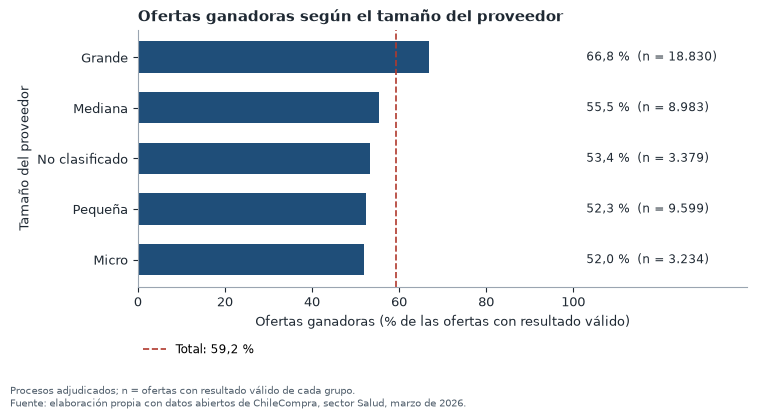

In [7]:
fig = grafico_proporciones(por_tamano, 'Ofertas ganadoras según el tamaño del proveedor',
                           'Tamaño del proveedor', etiquetas=ETIQUETAS_TAMANO)
guardar_figura(fig, FIGURAS / 'grafico1_tamano_proveedor.png')
plt.show()

**Interpretación.** Las empresas grandes ganan el 66,8 % de sus ofertas, 7,6 puntos porcentuales sobre el total (59,2 %) y 14,8 puntos sobre las micro (52,0 %). El orden coincide con la hipótesis: micro, pequeña, mediana y grande. Sin embargo, la diferencia no es gradual: micro, pequeña y mediana quedan en un rango de 3,5 puntos, y el salto ocurre en las grandes. Las grandes aportan además 18.830 de las 44.025 ofertas válidas (42,8 %), por lo que influyen fuertemente en el promedio general. La categoría «No clasificado» (53,4 %) se comporta como las empresas de menor tamaño.

## 6. Gráfico 2: ofertas ganadoras según el tipo de licitación
**Objetivo.** Responder la pregunta 2. Se mantiene el mismo diseño del gráfico anterior para que ambos se lean igual. Los tipos con menos de 100 ofertas válidas se dibujan en un tono más claro.

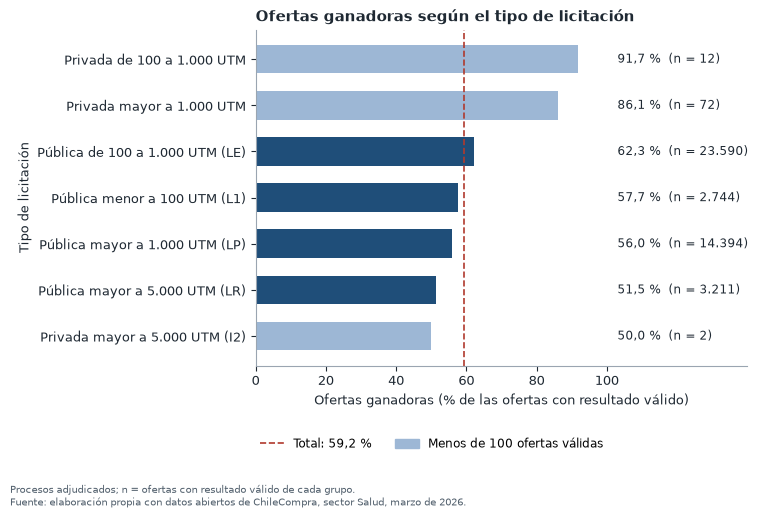

In [8]:
fig = grafico_proporciones(por_tipo, 'Ofertas ganadoras según el tipo de licitación',
                           'Tipo de licitación', etiquetas=ETIQUETAS_TIPO)
guardar_figura(fig, FIGURAS / 'grafico2_tipo_licitacion.png')
plt.show()

**Interpretación.** Entre las licitaciones públicas, que concentran el 99,8 % de las ofertas, la proporción de ganadoras va de 62,3 % en las de 100 a 1.000 UTM (LE) a 51,5 % en las mayores a 5.000 UTM (LR). En los tres tramos sobre 100 UTM el porcentaje disminuye a medida que aumenta el monto (LE, LP, LR); las menores a 100 UTM (L1), con 57,7 %, quedan bajo las LE y rompen ese orden. Las licitaciones privadas muestran valores extremos (91,7 %, 86,1 % y 50,0 %), pero con 12, 72 y 2 ofertas: no permiten concluir nada sobre ese tipo de proceso y solo se informan por transparencia.

## 7. Gráfico 3: plazo de cierre según el tipo de licitación
**Objetivo.** Responder la pregunta 3. Se usa un diagrama de caja porque interesa la distribución de una variable continua por categoría, no solo su valor central. Los tipos con menos de 30 licitaciones se muestran como puntos individuales: una caja con uno, cinco o diez datos sugeriría una distribución que no se puede estimar.

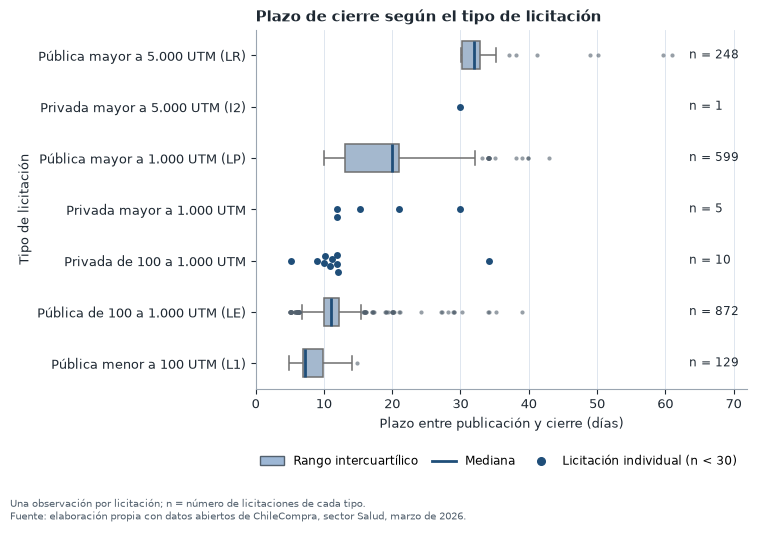

In [9]:
fig = grafico_plazos(datos, 'Plazo de cierre según el tipo de licitación', etiquetas=ETIQUETAS_TIPO)
guardar_figura(fig, FIGURAS / 'grafico3_plazo_cierre.png')
plt.show()

**Interpretación.** El plazo entre la publicación y el cierre aumenta con el monto de la licitación pública: la mediana es de 7,2 días en las menores a 100 UTM (L1), 11,0 en las de 100 a 1.000 UTM (LE), 20,0 en las mayores a 1.000 UTM (LP) y 32,0 en las mayores a 5.000 UTM (LR). Las cajas casi no se superponen entre tramos, lo que indica un patrón escalonado y no una diferencia de promedios producida por pocos casos. Los plazos más largos del conjunto, de hasta 61 días, pertenecen a licitaciones LR: son procesos de mayor monto y no errores de registro, por lo que se conservaron en la limpieza.

Leído junto con el gráfico 2, los procesos de mayor monto dan más tiempo para ofertar y, a la vez, registran una menor proporción de ofertas ganadoras. Es una coincidencia descriptiva; los datos no permiten afirmar que una cosa cause la otra.

## 8. Pruebas de las visualizaciones
Las funciones de `src/visualizacion.py` tienen pruebas propias: comprueban que cada figura tenga título, ejes, leyenda y fuente, que las barras estén ordenadas, que la entrada no se modifique y que las entradas inválidas se rechacen.

In [10]:
import io, unittest
suite = unittest.defaultTestLoader.loadTestsFromName('F4.test_visualizacion')
registro = io.StringIO()
resultado = unittest.TextTestRunner(stream=registro, verbosity=2).run(suite)
plt.close('all')
print(registro.getvalue())
assert resultado.wasSuccessful()

test_formato_numero_usa_separadores_locales (F4.test_visualizacion.PruebasVisualizacion.test_formato_numero_usa_separadores_locales) ... ok
test_grafico_plazos_separa_cajas_y_puntos (F4.test_visualizacion.PruebasVisualizacion.test_grafico_plazos_separa_cajas_y_puntos) ... ok
test_guardar_figura_crea_el_archivo (F4.test_visualizacion.PruebasVisualizacion.test_guardar_figura_crea_el_archivo) ... ok
test_plazos_rechaza_columnas_ausentes_y_datos_inconsistentes (F4.test_visualizacion.PruebasVisualizacion.test_plazos_rechaza_columnas_ausentes_y_datos_inconsistentes) ... ok
test_plazos_usa_una_fila_por_licitacion (F4.test_visualizacion.PruebasVisualizacion.test_plazos_usa_una_fila_por_licitacion) ... ok
test_proporciones_dibuja_una_barra_por_grupo_en_orden (F4.test_visualizacion.PruebasVisualizacion.test_proporciones_dibuja_una_barra_por_grupo_en_orden) ... ok
test_proporciones_incluye_titulo_ejes_leyenda_y_fuente (F4.test_visualizacion.PruebasVisualizacion.test_proporciones_incluye_titulo_ej

## 9. Síntesis
- **Hipótesis.** Se cumple en el orden, pero no como una tendencia gradual: la ventaja se concentra en las empresas grandes (66,8 % frente a 52,0 %–55,5 % en el resto).
- **Tipo de licitación.** En las licitaciones públicas sobre 100 UTM, la proporción de ofertas ganadoras baja al aumentar el monto, de 62,3 % a 51,5 %.
- **Plazos.** El plazo de cierre crece de forma escalonada con el monto, de 7,2 a 32,0 días de mediana.

**Limitaciones.** Los datos cubren un solo mes y un solo sector, por lo que no permiten generalizar ni observar tendencias. Los porcentajes se calculan por oferta: una licitación con muchos ítems pesa más que una con pocos. El tamaño del proveedor no está clasificado en 3.379 ofertas válidas. El análisis no controla otras variables, como el monto ofertado o el rubro, y no establece causalidad.

## 10. Reproducibilidad
Desde la raíz del repositorio:

```powershell
.\.venv\Scripts\python.exe -m pip install -r requirements.txt
.\.venv\Scripts\python.exe -m unittest F4.test_visualizacion -v
.\.venv\Scripts\python.exe F4\verificar_f4.py
```

El verificador ejecuta este notebook en un kernel nuevo, guarda sus salidas y registra el resultado en `evidencias/F4_ejecucion.json`. Las figuras quedan en `F4/figuras/` y son las que usan el informe final y la presentación.

## 11. Referencias
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering, 9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
- The Matplotlib development team. (s. f.). *Matplotlib documentation*. https://matplotlib.org/stable/
- Waskom, M. L. (2021). seaborn: Statistical data visualization. *Journal of Open Source Software, 6*(60), 3021. https://doi.org/10.21105/joss.03021
- ChileCompra. (s. f.). *Descargas de datos abiertos del sistema de compras públicas*. https://datos-abiertos.chilecompra.cl/descargas